# Path Generation code (4.1.1)



In [4]:
# Code development statement:

# Generative AI tools were used for assistance,

# code refinement and improving comments.

# All algorithms were independently reviewed, tested, and modified

# by the author to ensure correctness and understanding.

import random
import matplotlib.pyplot as plt

from image_processing import (
    find_colour_marker,
    detect_corner_markers,
    load_and_process_image,
    split_into_cells,
    detect_maze_walls,
    synchronise_walls,
    display_occupancy_map,
    draw_path_on_image,
    make_cells_black
)

from graph import (
    create_grid_graph,
    add_valid_edges,
    print_maze,
    print_maze_with_path
)

from path_finder import (
    command_optimal_path,
    path_to_commands
)

random.seed(42)

In [5]:
seed = 42
image_file = "./maze_images/cam_1_1.jpg"

# Task 1 - Occupancy map
unsafe_kernel_size = 7
unsafe_iterations = 3

# Task 3 - BFS
bfs_n = 9
bfs_start_node = 10
bfs_end_node = 70

# # Task 4 - PRM and Dijkstra
# prm_total_nodes_count = 30
# prm_connection_radius = 200
# prm_start_location = (50, 50)
# prm_goal_location = (450, 450)

# # Task 5 - RRT
# rrt_max_nodes_count = 500
# rrt_step_size = 40
# rrt_max_connection_length = 200
# rrt_start_location = (50, 50)
# rrt_goal_location = (450, 450)



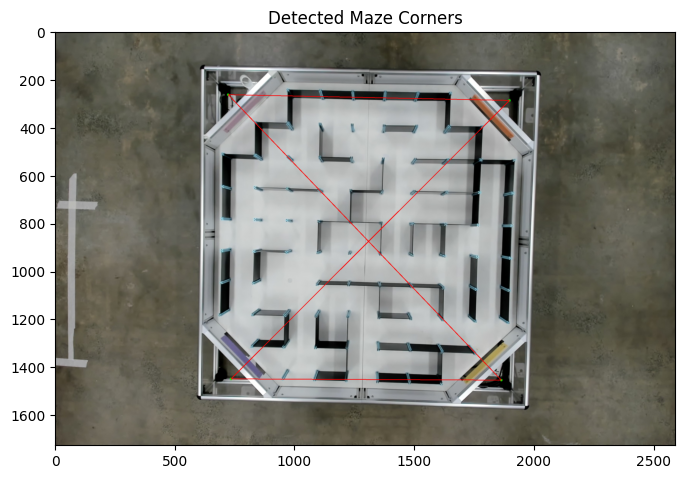

Image size: 900 x 900
Cell size: 100 x 100


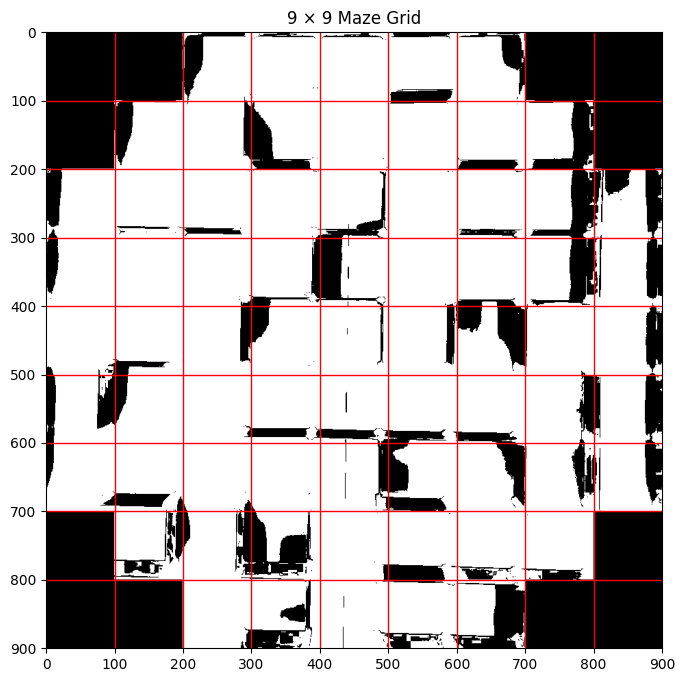


Digital maze with path:
+---+---+---+---+---+---+---+---+---+
|   |   |                   |   |   |
+---+---+   +   +   +---+   +---+---+
|   | S     |                   |   |
+---+   +   +---+   +   +---+---+---+
| •   •             |           |   |
+   +---+---+   +---+   +---+---+   +
| •             |               |   |
+   +   +   +---+---+   +---+---+   +
  •         |       |   |   |       |
+   +---+   +   +   +   +   +   +   +
| • |                           |   |
+   +   +   +---+---+---+---+   +   +
| •   •   •   •   • |       |   |   |
+---+---+   +   +   +---+   +   +---+
|   |   |   |   | •   •   •   G |   |
+---+---+   +---+   +---+---+---+---+
|   |   |       |           |   |   |
+---+---+   +---+   +---+---+---+---+

Perspective transformed image with final path:


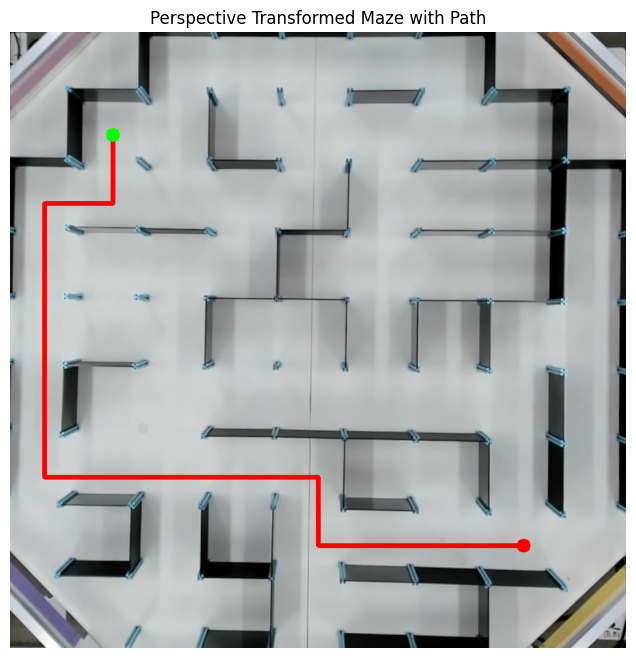


Path:
[10, 19, 18, 27, 36, 45, 54, 55, 56, 57, 58, 67, 68, 69, 70]
Number of moves: 14

Commands:
['r', 'r', 'f', 'r', 'f', 'l', 'f', 'f', 'f', 'f', 'l', 'f', 'f', 'f', 'f', 'r', 'f', 'l', 'f', 'f', 'f']

Command string:
rrfrflfffflffffrflfff

Number of commands: 21


In [6]:
def main():

    # ---------------------------------------------------------
    # 1. Process camera image
    # ---------------------------------------------------------

    binary, transformed_image = load_and_process_image(
        image_file
    )

    black_cells = [
        0, 1, 7, 8,
        9, 17,
        63, 71,
        72, 73, 79, 80]

    binary = make_cells_black(

        binary,

        black_cells,

        bfs_n,

        bfs_n

    )
    cells, cell_width, cell_height = split_into_cells(
        binary,
        bfs_n
    )

    print(
        "Image size:",
        binary.shape[1],
        "x",
        binary.shape[0]
    )

    print(
        "Cell size:",
        cell_width,
        "x",
        cell_height
    )

    display_occupancy_map(
        binary,
        cell_width,
        cell_height,
        bfs_n
    )

    # ---------------------------------------------------------
    # 2. Detect maze walls
    # ---------------------------------------------------------

    maze = detect_maze_walls(
        cells,
        bfs_n
    )

    # ---------------------------------------------------------
    # 3. Create graph representation
    # ---------------------------------------------------------

    graph = create_grid_graph(
        bfs_n
    )

    synchronise_walls(
        graph,
        maze,
        bfs_n
    )

    add_valid_edges(
        graph,
        bfs_n
    )

    # ---------------------------------------------------------
    # 4. Find command-optimal path
    # ---------------------------------------------------------

    path, commands = command_optimal_path(
        graph,
        bfs_start_node,
        bfs_end_node,
        start_direction="N"
    )

    if path is None:

        print("\nNo path found.")

    else:

        # -----------------------------------------------------
        # Digital maze with path
        # -----------------------------------------------------

        print("\nDigital maze with path:")

        print_maze_with_path(
            graph,
            path,
            bfs_n,
            bfs_n
        )

        # -----------------------------------------------------
        # Draw final path on perspective-transformed image
        # -----------------------------------------------------

        path_image = draw_path_on_image(
            transformed_image,
            path,
            bfs_n,
            bfs_n
        )

        print(
            "\nPerspective transformed image "
            "with final path:"
        )

        plt.figure(figsize=(8, 8))

        plt.imshow(path_image)

        plt.title(
            "Perspective Transformed Maze with Path"
        )

        plt.axis("off")

        plt.show()

        # -----------------------------------------------------
        # Path information
        # -----------------------------------------------------

        print("\nPath:")
        print(path)

        print(
            "Number of moves:",
            len(path) - 1
        )

        # -----------------------------------------------------
        # Commands
        # -----------------------------------------------------

        print("\nCommands:")
        print(commands)

        print("\nCommand string:")
        print("".join(commands))

        print(
            "\nNumber of commands:",
            len(commands)
        )


if __name__ == "__main__":
    main()